- uncomment to install library

In [ ]:
#! pip install pydot

In [ ]:
#! pip install graphviz 

## Setup Experiment

- set parameter

In [1]:
labels = ['AF', 'N']

fs = 250

feature_type = "resnet50" # ubah ke 'vgg16', 'resnet50', 'densenet121'

threshold_acc = 0.98

test_size_split=0.15

EPOCHS = 2

BATCH_SIZE = 32

In [2]:
import os
import datetime

experiment_folder = "experiment/"

experiment_name = feature_type + "_" + datetime.datetime.now().strftime("%Y_%m_%d__%H_%M_%S")

if not os.path.exists(experiment_folder + experiment_name) :
    os.mkdir(experiment_folder + experiment_name)

In [3]:
dataset_folder = 'dataset/'

filenames = []
for filename in os.listdir(dataset_folder):
    if filename.find(".npz") > -1:
        filenames.append(filename)

In [4]:
filenames

['test_vgg16_feature.npz',
 'test_y.npz',
 'train_vgg16_feature.npz',
 'train_y.npz',
 'X_image.npz',
 'X_image_AFDB.npz',
 'y_target.npz',
 'y_target_AFDB.npz']

In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Load dataset

- load target data (`y`)

In [6]:
y = np.load(dataset_folder + 'y_target.npz')['y']

- load image data (`X`)

In [7]:
X = np.load(dataset_folder + 'X_image.npz')['X']

## Splitting Dataset

In [8]:
unique, counts = np.unique(y, return_counts=True)

print(dict(zip([labels[int(i)] for i  in unique], counts)))

{'AF': 30000, 'N': 30000}


- splitting data

In [9]:
from keras.utils.np_utils import to_categorical

y = to_categorical(y)

Using TensorFlow backend.


In [10]:
x_idx = np.array(list(range(len(X))))

In [11]:
x_idx_train, x_idx_test, y_train, y_test = train_test_split(
                                    x_idx, y, 
                                    test_size=test_size_split,
                                    random_state=42)

In [12]:
X_test = X[x_idx_test]
X_train = X[x_idx_train]


print(y_train.shape, X_train.shape, y_test.shape, X_test.shape)

X = []
y = []
x_idx = []
x_idx_train = []
x_idx_test = []

(51000, 2) (51000, 224, 224, 3) (9000, 2) (9000, 224, 224, 3)


## Utils Function

In [13]:
import json

def writeJson_config(Path, Name, Data, append):
    mode = 'a+' if append else 'w'
    full_path = Path + Name

    with open(full_path, mode=mode) as json_config:
        json.dump(Data, json.load(json_config) if append else json_config)
    
    return 'success' 


In [14]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5, 5))
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    
    plt.savefig(experiment_folder + experiment_name +
               "/plot-confusion-matrix-%s.png" % feature_type)
    
    plt.show()

In [15]:
def evaluate_model(history):
    
    fig1, ax_acc = plt.subplots()
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Model - Accuracy')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.grid()
    plt.show()
    fig1.savefig(experiment_folder + experiment_name +
               "/plot-accuracy-%s.png" % feature_type)
    
    fig2, ax_loss = plt.subplots()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Model- Loss')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.grid()
    plt.show()
    fig2.savefig(experiment_folder + experiment_name +
               "/plot-loss-%s.png" % feature_type)

## Building Convolutional Neural Network

- Import Keras library

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow import keras

In [17]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.densenet import DenseNet121

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input as prepro_vgg16
from tensorflow.keras.applications.resnet50 import preprocess_input as prepro_resnet50
from tensorflow.keras.applications.densenet import preprocess_input as prepro_densenet121

- Buat CNN Model dengan aritektur network : 
`CONV-POOL-CONV-POOL-CONV-POOL-FC`
- CONV : 1D Convolutional Layer
- POOL : MAX Pooling Layer
- FC   : Dense Layer + Activation

In [18]:
def feature_extraction_model():
    if feature_type == "vgg16" :
        return VGG16(weights='imagenet', include_top=False)
    elif feature_type == "resnet50" :
        return ResNet50(weights='imagenet', include_top=False)
    elif feature_type == "densenet121" :
        return DenseNet121(weights='imagenet', include_top=False)
    else :
        raise("feature %s not found!" % feature_type)
        return None

In [19]:
def cnn_model(input_shape):
    
    base_model = feature_extraction_model()
    base_model.trainable = False
    
    inputs = keras.Input(shape=(224, 224, 3))
    
    x = base_model(inputs, training=False)
    
    x = Conv2D(filters=64,
                     kernel_size=3,
                     activation='relu',
                     input_shape=input_shape)(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters=64,
                     kernel_size=3,
                     activation='relu',
                     input_shape=input_shape)(x)
    x = BatchNormalization()(x)
    x = MaxPool2D(pool_size=2,
                        strides=2,
                        padding='same')(x)
    

    # Fully Connected layer (FC)
    x = Flatten()(x)
    x = Dense(256, 
                activation='relu')(x)
    x = Dense(64, 
                activation='relu')(x)
    outputs = Dense(2, 
                    activation='softmax')(x)
              
    model = keras.Model(inputs, outputs)
    
    model.summary()
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy',
                  metrics = ['accuracy'])

    return model

- sekarang kita akan melakukan proses training model dengan memanfaatkan `.fit()` pada model yang kita buat diatas.
- selain itu kita gunakan juka teknik `EarlyStoping()` untuk menghentikan proses training jika terjadi divergensi pada validation data yang diakibatkan oleh overfitting. 
- pada `EarlyStoping()` kita gunakan parmeter `patience=8` yang artinya jika proses training untuk 8 epoch tidak terjadi peningkatan maka hentikan proses training.

In [20]:
def check_model(model_, x, y, x_test, y_test, epochs_, batch_size_):
    callbacks = [EarlyStopping(monitor='val_loss', patience=3),
                 ModelCheckpoint(filepath='cnn_classif_best_model.h5', monitor='val_loss', save_best_only=True)]

    hist = model_.fit(x, 
                      y,
                      epochs=epochs_,
                      callbacks=callbacks, 
                      batch_size=batch_size_,
                      shuffle=True,
                      #validation_split=0.15)
                      validation_data=(x_test, y_test))
    #model_.load_weights('cnn_classif_best_model.h5')
    return hist 

### Train Model CNN

- jalankan proses training dengan `EPOCH` sebanyak 16 dan `BATCH_SIZE` sebesar 32

In [21]:
input_shape = X_train[0].shape

model = cnn_model(input_shape)

C:\Users\yunus\Anaconda3\envs\GPU_ENV\lib\site-packages\keras_applications\resnet50.py:265: UserWarning: The output shape of `ResNet50(include_top=False)` has been changed since Keras 2.2.0.
  warnings.warn('The output shape of `ResNet50(include_top=False)` '


_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 224, 224, 3)       0         
_________________________________________________________________
resnet50 (Model)             multiple                  23587712  
_________________________________________________________________
conv2d (Conv2D)              (None, 5, 5, 64)          1179712   
_________________________________________________________________
batch_normalization (BatchNo (None, 5, 5, 64)          256       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 3, 3, 64)          36928     
_________________________________________________________________
batch_normalization_1 (Batch (None, 3, 3, 64)          256       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 2, 2, 64)          0         
__________

- Save model arhitecture

In [22]:
with open(experiment_folder + experiment_name +
              '/model_summary_%s.txt' % feature_type, 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

- Train model

In [23]:
history=check_model(model, X_train, y_train, X_test, y_test, EPOCHS, BATCH_SIZE)


Train on 51000 samples, validate on 9000 samples
Epoch 1/2
51000/51000 [==============================] - 4490s 88ms/step - loss: 0.0590 - acc: 0.9795 - val_loss: 0.0216 - val_acc: 0.9931
Epoch 2/2
51000/51000 [==============================] - 4758s 93ms/step - loss: 0.0214 - acc: 0.9926 - val_loss: 0.0217 - val_acc: 0.9928


- Save model binary

In [24]:
model.save(experiment_folder + experiment_name + "/CNN_Classification_model_%s.h5" % feature_type)

- save model training history (log)

In [25]:
pd.DataFrame.from_dict(history.history).to_csv( experiment_folder + experiment_name +
                                               '/history_train_CNN_feature_%s.csv' % feature_type, index=False)

# Evaluate Model

- Plot Accuracy vs Epochs
- Plot Loss vs Epochs

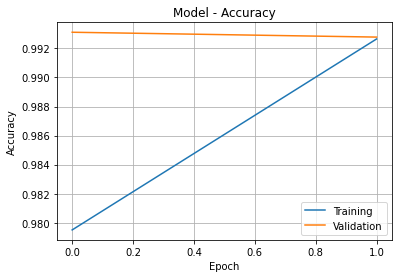

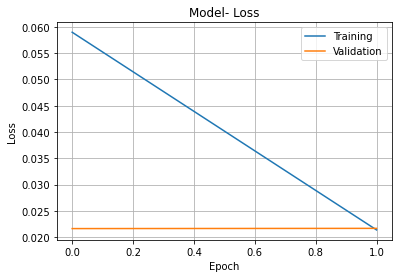

In [26]:
evaluate_model(history)    

- Plot Confusion Matrix

In [27]:
# predict test data
y_pred=model.predict(X_test)

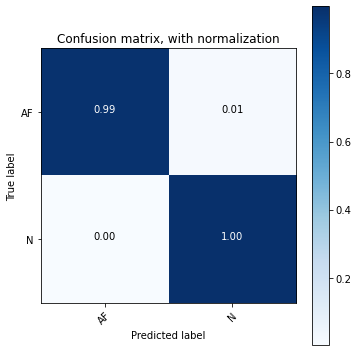

In [28]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plot_confusion_matrix(cnf_matrix, classes=['AF', 'N'],normalize=True,
                      title='Confusion matrix, with normalization')

- dari hasil plot confusion matrix, dapat dilihat tiap kelas memiliki banyak TRUE POSITIVE predicted data
- semakin gelap kebiruan menunjukan banyaknya hasil predicted label untuk true label tersebut

- Plot Classification Report

In [29]:
print(classification_report(y_test.argmax(axis=1), 
                            y_pred.argmax(axis=1), 
                            target_names=['AF', 'N']))

              precision    recall  f1-score   support

          AF       1.00      0.99      0.99      4445
           N       0.99      1.00      0.99      4555

    accuracy                           0.99      9000
   macro avg       0.99      0.99      0.99      9000
weighted avg       0.99      0.99      0.99      9000



- Jika kita lihat, nilai report untuk seluruh klas juga bagus, 
- Nilai recall dan precission juga tinggi, menunjukan model mampu memprediksi data dengan baik untuk seluruh data pada sclass tersebut 

- save report

In [30]:
report_dict = classification_report(y_test.argmax(axis=1), 
                            y_pred.argmax(axis=1), 
                            target_names=['AF', 'N'],
                            output_dict=True)

writeJson_config(experiment_folder + experiment_name + "/", 
                 "report-%s.json" % feature_type, report_dict, False)

'success'

- save model spec

In [31]:
model_spec_dict = {}
model_spec_dict['train_size'] = [y_train.shape, X_train.shape]
model_spec_dict['test_size'] =  [y_test.shape, X_test.shape]
model_spec_dict['epoch'] =  EPOCHS
model_spec_dict['batch_size'] =  BATCH_SIZE
model_spec_dict['test_size_split'] = test_size_split

writeJson_config(experiment_folder + experiment_name + "/", 
                 "model-spec-%s.json" % feature_type, model_spec_dict, False)

'success'

- Update Experiment Header

In [32]:
with open(experiment_folder + 
              '/experiment_header.txt', 'a') as f:
    f.write("Experiment Name \t: %s \n" % experiment_name)
    f.write("Accuracy \t\t: %.4f\n\n\n" % report_dict['accuracy'])

- move best experiment to main dir (>= threshold accuracy)

In [34]:
if report_dict['accuracy'] >= threshold_acc:
    import shutil
    
    shutil.copy(experiment_folder + experiment_name + "/plot-accuracy-%s.png" % feature_type, "5. plot-accuracy-%s.png" % feature_type)
    shutil.copy(experiment_folder + experiment_name + "/plot-loss-%s.png" % feature_type, "5. plot-loss-%s.png" % feature_type)
    shutil.copy(experiment_folder + experiment_name + "/plot-confusion-matrix-%s.png" % feature_type, "5. plot-confusion-matrix-%s.png" % feature_type)
    shutil.copy(experiment_folder + experiment_name + "/history_train_CNN_feature_%s.csv" % feature_type, "history_train_CNN_feature_%s.csv" % feature_type)
    shutil.copy(experiment_folder + experiment_name + "/report-%s.json" % feature_type, "classification-report-%s.json" % feature_type)
    shutil.copy(experiment_folder + experiment_name + "/CNN_Classification_model_%s.h5" % feature_type, "CNN_Classification_model_%s.h5" % feature_type)
    print("[INFO] success move best result to main dir!")
else :
    print("[INFO] accuracy %.4f, is under threshold !" % report_dict['accuracy'])

[INFO] success move best result to main dir!
